# Random Forest Scaling Experiment

**Experiment 3**: (a) Vary `n_estimators` from 1 to 200 (`max_depth=None` fixed); (b) Vary `max_depth` from 1 to 20 (`n_estimators=100` fixed). OOB accuracy is tracked alongside test accuracy.

**Datasets**: Breast Cancer, Adult Income, Covertype, MNIST (Full - 10 classes)

---
**AZ (Azərbaycan dilində izah):** Bu notebook layihə brifinqinin **§3.3 "Random Forest scaling"** bəndini yerinə yetirir və struktur baxımından `adaboostscale.ipynb` ilə eynidir (konfiqurasiya bloku, yaddaş statistikası, hər dataset üçün ayrıca CSV saxlama, qrafiklər, overfitting analizi, sklearn müqayisəsi).

**Fərq AdaBoost-dan:** AdaBoost-da `staged_predict` metodu sayəsində **BİR** model 200 dövr üçün öyrədilir və hər dövrün nəticəsi "pulsuz" alınır (çünki ardıcıl modeldir — hər stump əvvəlkinin çəkilərinə əsaslanır). Random Forest-də isə ağaclar **bir-birindən müstəqildir** (bagging), amma bizim `RandomForestClassifier` sinfimiz hər ağacın OOB indekslərini kənara ayrıca çıxarmır — ona görə `n_estimators` sweep-də hər nöqtə üçün **yenidən `fit()` çağırırıq** (bu, həm sadə, həm də etibarlıdır, çünki sinfin öz `oob_score_`-una etibar edirik).

**EN (English explanation):** This notebook implements the **§3.3 "Random Forest scaling"** section of the project brief and mirrors the structure of `adaboostscale.ipynb` (config block, memory stats, per-dataset CSV saving, plots, overfitting analysis, sklearn comparison).

**Difference from AdaBoost:** AdaBoost's `staged_predict` lets **ONE** model trained for 200 rounds yield every round's prediction "for free" (since it's a sequential model — each stump depends on the previous round's sample weights). Random Forest's trees are **independent** (bagging), but our given `RandomForestClassifier` class does not expose each tree's OOB indices separately — so for the `n_estimators` sweep we **retrain from scratch** at every point (simpler and safer, and it lets us rely on the class's own `oob_score_` computation without re-implementing it).


In [1]:
# WORTH READING

# We did experiments with various values of step size and sample size.
# But we "tried" to make the experiment as fault-tolerant as possible.
# We did so by storing the experiment results in csv files as per dataset (training done for one dataset, dump results in csv).

# There is a possibility that we may change the step size to be 10.
# Or use different approach to meet the requirements.

# As of 14 July 2026, around 12:20, I will try "log2" for max_features.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# ============================================
# RANDOM FOREST SCALING EXPERIMENT
# Experiment 3: (a) vary n_estimators 1->200, (b) vary max_depth 1->20
# OOB accuracy tracked alongside test accuracy (per project brief)
# ============================================
import time
import sys
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Add parent directory to path
sys.path.append("..")

from src.utils.preprocessing import (
    load_breast_cancer_data,
    load_adult_income_data,
    load_covertype_data,
    load_mnist_data,
)
from src.utils.rf_scale import RandomForestClassifier
from src.metrics.evaluation import accuracy_calculation, f1_score

# Set style
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

time_start = time.perf_counter()

print("=" * 60)
print("RANDOM FOREST SCALING EXPERIMENT Started")
print("=" * 60)

RANDOM FOREST SCALING EXPERIMENT Started


# Configuration

In [4]:
# ============================================
# EXPERIMENT CONFIGURATION
# ============================================
CONFIG = {
    "max_estimators": 200,  # Maximum number of trees for the (a) sweep
    "step": 5,  # Record at 1, 5, 10, 15, ..., 200
    "max_depth_values": list(range(1, 21)),  # Depth values for the (b) sweep
    "fixed_n_estimators_for_depth_sweep": 100,  # n_estimators held fixed in (b)
    "test_size": 0.2,  # Train/test split ratio
    "random_state": 42,  # Fixed seed for reproducibility
    "sklearn_n_estimators": 200,  # For sklearn comparison
    "covertype_sample_size": 5_000,  # Covertype sample size (min 5000 per spec)
    "mnist_sample_size": 5_000,  # MNIST sample size
    "max_features": "log2",  # max features to in a tree. Can be strings of ("log2", "sqrt"), some int, or None that will use all features
}

# Extract values for easy access
MAX_ESTIMATORS = CONFIG["max_estimators"]
STEP = CONFIG["step"]
MAX_DEPTH_VALUES = CONFIG["max_depth_values"]
FIXED_N_FOR_DEPTH = CONFIG["fixed_n_estimators_for_depth_sweep"]
TEST_SIZE = CONFIG["test_size"]
RANDOM_STATE = CONFIG["random_state"]
SKLEARN_N_ESTIMATORS = CONFIG["sklearn_n_estimators"]
COVERTYPE_SAMPLE_SIZE = CONFIG.get("covertype_sample_size")
MNIST_SAMPLE_SIZE = CONFIG.get("mnist_sample_size")
MAX_FEATURES = CONFIG.get("max_features")

# Create rounds list: [1, 2, 3, 5, 10, 15, ..., 200]
# (dense at the start so the early-variance behaviour is visible)
N_ESTIMATORS_LIST = (
    [1, 3]
    + [i * 5 for i in range(1, 6)]
    + [30, 40, 50]
    + [j * 10 for j in range(6, 21)]
)


print("\n" + "=" * 60)
print("EXPERIMENT CONFIGURATION")
print("=" * 60)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(
    f"\n  (a) n_estimators points: {N_ESTIMATORS_LIST[:8]}...{N_ESTIMATORS_LIST[-3:]}  ({len(N_ESTIMATORS_LIST)} points)"
)
print(
    f"  (b) max_depth points:    {MAX_DEPTH_VALUES}  ({len(MAX_DEPTH_VALUES)} points)"
)
print("=" * 60)


EXPERIMENT CONFIGURATION
  max_estimators: 200
  step: 5
  max_depth_values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  fixed_n_estimators_for_depth_sweep: 100
  test_size: 0.2
  random_state: 42
  sklearn_n_estimators: 200
  covertype_sample_size: 5000
  mnist_sample_size: 5000
  max_features: log2

  (a) n_estimators points: [1, 3, 5, 10, 15, 20, 25, 30]...[180, 190, 200]  (25 points)
  (b) max_depth points:    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]  (20 points)


# Helper functions

In [5]:
def get_memory_usage(obj):
    """Get memory usage of pandas or numpy object in MB."""
    if hasattr(obj, "memory_usage"):
        mem = obj.memory_usage(deep=True)
        if hasattr(mem, "sum"):
            return mem.sum() / 1024**2
        else:
            return mem / 1024**2
    elif hasattr(obj, "nbytes"):
        return obj.nbytes / 1024**2
    else:
        return 0


def save_scaling_results(name, sweep_kind, result, sample_size=None, X=None, y=None):
    """
    Saves scaling results to ../rf_scaling_files/ and metadata.
    """
    # Define directory and naming variables
    save_dir = "../rf_scaling_files"
    os.makedirs(save_dir, exist_ok=True)
    size_str = str(sample_size) if sample_size is not None else "full"

    x_key = "n_estimators" if sweep_kind == "n_estimators" else "max_depth"

    # 1. Save detailed results
    df = pd.DataFrame(
        {
            x_key: result[x_key],
            "train_acc": result["train_acc"],
            "test_acc": result["test_acc"],
            "oob_acc": result["oob_acc"],
            "train_f1": result["train_f1"],
            "test_f1": result["test_f1"],
            "fit_time_sec": result["fit_time"],
        }
    )
    filename = f"{save_dir}/rf_scaling_{sweep_kind}_{name}_size{size_str}_details.csv"
    df.to_csv(filename, index=False)
    print(f"   Results saved: {filename}")

    # 2. Save metadata
    best_idx = int(np.argmax(result["test_acc"]))
    metadata = {
        "dataset": name,
        "sweep": sweep_kind,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "points_tested": len(result[x_key]),
        f"best_{x_key}": result[x_key][best_idx],
        "best_test_accuracy": result["test_acc"][best_idx],
        "best_oob_accuracy": result["oob_acc"][best_idx],
        "best_test_f1": result["test_f1"][best_idx],
        "sample_size": sample_size if sample_size is not None else "full",
        "n_features": X.shape[1] if X is not None else "unknown",
        "n_classes": len(np.unique(y)) if y is not None else "unknown",
    }
    metadata_df = pd.DataFrame([metadata])
    metadata_filename = (
        f"{save_dir}/rf_scaling_{sweep_kind}_{name}_size{size_str}_metadata.csv"
    )
    metadata_df.to_csv(metadata_filename, index=False)
    print(f"   Metadata saved: {metadata_filename}")

# Load datasets

In [6]:
# Helper function to get memory usage
memory_stats = []

# Load Breast Cancer
X_bc, y_bc, _ = load_breast_cancer_data(optimize_memory=True, verbose=False)
memory_stats.append(
    {
        "Dataset": "Breast_Cancer",
        "X_memory_mb": get_memory_usage(X_bc),
        "y_memory_mb": get_memory_usage(y_bc),
        "X_type": type(X_bc).__name__,
        "X_dtype": X_bc.dtypes if hasattr(X_bc, "dtypes") else X_bc.dtype,
    }
)

# Load Adult Income
X_adult, y_adult, _ = load_adult_income_data(
    drop_categorical=True, optimize_memory=True, verbose=False
)
y_adult_binary = (y_adult.str.replace(".", "", regex=False) == ">50K").astype(int)
memory_stats.append(
    {
        "Dataset": "Adult_Income",
        "X_memory_mb": get_memory_usage(X_adult),
        "y_memory_mb": get_memory_usage(y_adult_binary),
        "X_type": type(X_adult).__name__,
        "X_dtype": X_adult.dtypes if hasattr(X_adult, "dtypes") else X_adult.dtype,
    }
)

# Load Covertype with subsampling
X_cover, y_cover, _ = load_covertype_data(
    drop_categorical=True, optimize_memory=True, verbose=False
)
if COVERTYPE_SAMPLE_SIZE is not None and COVERTYPE_SAMPLE_SIZE < len(X_cover):
    print(f"  Subsampling Covertype: {len(X_cover)} -> {COVERTYPE_SAMPLE_SIZE} samples")
    sample_indices = np.random.RandomState(RANDOM_STATE).choice(
        len(X_cover), COVERTYPE_SAMPLE_SIZE, replace=False
    )
    X_cover = X_cover.iloc[sample_indices]
    y_cover = y_cover.iloc[sample_indices]
else:
    print(f"  Using full Covertype dataset: {len(X_cover)} samples")
memory_stats.append(
    {
        "Dataset": "Covertype",
        "X_memory_mb": get_memory_usage(X_cover),
        "y_memory_mb": get_memory_usage(y_cover),
        "X_type": type(X_cover).__name__,
        "X_dtype": X_cover.dtypes if hasattr(X_cover, "dtypes") else X_cover.dtype,
    }
)

# Load MNIST with subsampling
X_mnist, y_mnist, _ = load_mnist_data(
    optimize_memory=True, verbose=False, return_numpy=False
)
if MNIST_SAMPLE_SIZE is not None and MNIST_SAMPLE_SIZE < len(X_mnist):
    print(f"  Subsampling MNIST: {len(X_mnist)} -> {MNIST_SAMPLE_SIZE} samples")
    sample_indices = np.random.RandomState(RANDOM_STATE).choice(
        len(X_mnist), MNIST_SAMPLE_SIZE, replace=False
    )
    X_mnist = X_mnist.iloc[sample_indices]
    y_mnist = y_mnist.iloc[sample_indices]
else:
    print(f"  Using full MNIST dataset: {len(X_mnist)} samples")
memory_stats.append(
    {
        "Dataset": "MNIST",
        "X_memory_mb": get_memory_usage(X_mnist),
        "y_memory_mb": get_memory_usage(y_mnist),
        "X_type": type(X_mnist).__name__,
        "X_dtype": X_mnist.dtypes if hasattr(X_mnist, "dtypes") else X_mnist.dtype,
    }
)

# Process Covertype
y_cover_flat = y_cover.values.ravel()

# Create datasets dictionary
datasets = {
    "Breast_Cancer": (X_bc.values, y_bc.values),
    "Adult_Income": (X_adult.values, y_adult_binary.values),
    "Covertype": (X_cover.values, y_cover_flat),
    "MNIST": (X_mnist, y_mnist),
}

print("\n" + "=" * 60)
print("DATASETS LOADED")
print("=" * 60)

total_memory = 0
for name, (X, y) in datasets.items():
    if hasattr(X, "memory_usage"):
        mem = X.memory_usage(deep=True)
        x_mem = mem.sum() / 1024**2 if hasattr(mem, "sum") else mem / 1024**2
    else:
        x_mem = X.nbytes / 1024**2

    if hasattr(y, "memory_usage"):
        mem = y.memory_usage(deep=True)
        y_mem = mem.sum() / 1024**2 if hasattr(mem, "sum") else mem / 1024**2
    else:
        y_mem = y.nbytes / 1024**2

    total_memory += x_mem + y_mem

    print(f"\n{name}:")
    print(f"  Shape: {X.shape}")
    print(f"  Classes: {np.unique(y)}")
    print(f"  X type: {type(X).__name__}")
    print(f"  X memory: {x_mem:.1f} MB")
    print(f"  y memory: {y_mem:.1f} MB")
    print(f"  Total memory: {x_mem + y_mem:.1f} MB")

print(f"\n{'=' * 60}")
print(f"TOTAL MEMORY FOR ALL DATASETS: {total_memory:.1f} MB")
print("=" * 60)

  Subsampling Covertype: 581012 -> 5000 samples
  Subsampling MNIST: 70000 -> 5000 samples

DATASETS LOADED

Breast_Cancer:
  Shape: (569, 30)
  Classes: [0 1]
  X type: ndarray
  X memory: 0.1 MB
  y memory: 0.0 MB
  Total memory: 0.1 MB

Adult_Income:
  Shape: (48842, 6)
  Classes: [0 1]
  X type: ndarray
  X memory: 2.2 MB
  y memory: 0.4 MB
  Total memory: 2.6 MB

Covertype:
  Shape: (5000, 10)
  Classes: [1 2 3 4 5 6 7]
  X type: ndarray
  X memory: 0.4 MB
  y memory: 0.0 MB
  Total memory: 0.4 MB

MNIST:
  Shape: (5000, 784)
  Classes: [0 1 2 3 4 5 6 7 8 9]
  X type: DataFrame
  X memory: 29.9 MB
  y memory: 0.1 MB
  Total memory: 30.0 MB

TOTAL MEMORY FOR ALL DATASETS: 33.2 MB


# Core Experiment Function — (a) n_estimators scaling

**AZ:** `max_depth=None` sabit saxlanılır. Hər `n_estimators` dəyəri üçün modeli **sıfırdan yenidən qururuq** (çünki `RandomForestClassifier` bizim üçün per-tree OOB indekslərini ayrıca saxlamır — ona görə "staged" trick tətbiq etmirik, sadəcə hər nöqtədə yenidən `fit()` çağırırıq və sinifin öz `oob_score_`-undan istifadə edirik).

**EN:** `max_depth=None` is held fixed. For each `n_estimators` value we **retrain the model from scratch** (since `RandomForestClassifier` doesn't expose per-tree OOB indices to us — so we don't apply a "staged" trick here, we simply call `fit()` again at each point and rely on the class's own `oob_score_`).


In [7]:
def run_rf_scaling_n_estimators(X, y, dataset_name, n_estimators_list=None):
    if n_estimators_list is None:
        n_estimators_list = N_ESTIMATORS_LIST

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
    f1_mean = "binary" if len(np.unique(y)) == 2 else "macro"

    # 1. Train ONCE
    model = RandomForestClassifier(
        n_estimators=max(n_estimators_list),
        oob_score=True,
        n_jobs=-2,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_s, y_train)

    # 2. Get staged metrics
    all_oob_scores = model.staged_oob_score(X_train_s, y_train)  # New OOB tracking
    all_preds_test = list(model.staged_predict(X_test_s))
    all_preds_train = list(model.staged_predict(X_train_s))

    results = {
        k: []
        for k in [
            "n_estimators",
            "train_acc",
            "test_acc",
            "oob_acc",
            "train_f1",
            "test_f1",
            "fit_time",
        ]
    }

    results["dataset"] = dataset_name

    for n in n_estimators_list:
        pred_train = all_preds_train[n - 1]
        pred_test = all_preds_test[n - 1]

        results["n_estimators"].append(n)
        results["train_acc"].append(accuracy_calculation(y_train, pred_train))
        results["test_acc"].append(accuracy_calculation(y_test, pred_test))
        results["oob_acc"].append(all_oob_scores[n - 1])  # Populate with staged OOB
        results["train_f1"].append(f1_score(y_train, pred_train, mean=f1_mean))
        results["test_f1"].append(f1_score(y_test, pred_test, mean=f1_mean))
        results["fit_time"].append(0)

    return results

# Core Experiment Function — (b) max_depth scaling

**AZ:** `n_estimators=100` (CONFIG-dəki `fixed_n_estimators_for_depth_sweep`) sabit saxlanılır, `max_depth` 1-dən 20-yə qədər dəyişdirilir. Hər dərinlik dəyəri fərqli ağac strukturu deməkdir, ona görə burada da hər nöqtədə yenidən öyrətmə **məcburidir** (staging mümkün deyil).

**EN:** `n_estimators=100` (`fixed_n_estimators_for_depth_sweep` in CONFIG) is held fixed while `max_depth` is varied from 1 to 20. Each depth value implies a different tree structure, so retraining at every point is **mandatory** here too (no staging is possible).


In [8]:
def run_rf_scaling_max_depth(
    X, y, dataset_name, max_depth_list=None, max_features=MAX_FEATURES
):
    """
    Run Random Forest scaling experiment varying max_depth (n_estimators fixed).
    Retrains the model at every point and records train/test/OOB accuracy + F1.

    Returns:
    --------
    dict: Results containing train/test/OOB metrics for each max_depth
    """

    if max_depth_list is None:
        max_depth_list = MAX_DEPTH_VALUES

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    f1_mean = "binary" if len(np.unique(y)) == 2 else "macro"

    train_acc, test_acc, oob_acc = [], [], []
    train_f1, test_f1, fit_times = [], [], []

    for depth in max_depth_list:
        t0 = time.perf_counter()
        model = RandomForestClassifier(
            n_estimators=FIXED_N_FOR_DEPTH,  # tree count is FIXED in this sweep
            max_depth=depth,
            max_features=max_features,
            oob_score=True,
            n_jobs=-2,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train_scaled, y_train)
        fit_times.append(time.perf_counter() - t0)

        pred_train = model.predict(X_train_scaled)
        pred_test = model.predict(X_test_scaled)

        train_acc.append(accuracy_calculation(y_train, pred_train))
        test_acc.append(accuracy_calculation(y_test, pred_test))
        oob_acc.append(model.oob_score_ if model.oob_score_ is not None else np.nan)
        train_f1.append(f1_score(y_train, pred_train, mean=f1_mean))
        test_f1.append(f1_score(y_test, pred_test, mean=f1_mean))

    return {
        "dataset": dataset_name,
        "max_depth": max_depth_list,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "oob_acc": oob_acc,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "fit_time": fit_times,
    }

# Training Loop

In [9]:
def train_dataset_rf(name, X, y, sample_size=None):
    """
    Run BOTH the (a) n_estimators sweep and (b) max_depth sweep for a
    single dataset, saving results immediately after each.
    """

    print(f"[{time.strftime('%H:%M:%S')}] Starting {name}...")

    # --- (a) n_estimators sweep ---
    print(f"  (a) n_estimators sweep: {len(N_ESTIMATORS_LIST)} points, max_depth=None")
    start = time.perf_counter()
    result_n = run_rf_scaling_n_estimators(X, y, name, N_ESTIMATORS_LIST)
    elapsed_n = time.perf_counter() - start
    print(f"      done ({elapsed_n:.2f}s)")
    save_scaling_results(name, "n_estimators", result_n, sample_size, X, y)

    # --- (b) max_depth sweep ---
    print(
        f"  (b) max_depth sweep: {len(MAX_DEPTH_VALUES)} points, n_estimators={FIXED_N_FOR_DEPTH}"
    )
    start = time.perf_counter()
    result_depth = run_rf_scaling_max_depth(X, y, name, MAX_DEPTH_VALUES)
    elapsed_depth = time.perf_counter() - start
    print(f"      done ({elapsed_depth:.2f}s)")
    save_scaling_results(name, "max_depth", result_depth, sample_size, X, y)

    print(
        f"[{time.strftime('%H:%M:%S')}] Finished {name}! (total {elapsed_n + elapsed_depth:.2f}s)"
    )

    return name, result_n, result_depth


def run_all_rf(datasets, skip_bc_and_adult=False):
    """
    Run Random Forest scaling experiments (both sweeps) on all datasets.
    Automatically loads existing results if available to save time;
    otherwise, performs training and saves results to ../rf_scaling_files/.
    """

    print("\nStarting Random Forest scaling experiments...")
    print(
        f"(a) n_estimators: {N_ESTIMATORS_LIST[0]}..{N_ESTIMATORS_LIST[-1]} ({len(N_ESTIMATORS_LIST)} points, max_depth=None)"
    )
    print(
        f"(b) max_depth:    {MAX_DEPTH_VALUES[0]}..{MAX_DEPTH_VALUES[-1]} ({len(MAX_DEPTH_VALUES)} points, n_estimators={FIXED_N_FOR_DEPTH})"
    )
    print("=" * 60)
    start = time.perf_counter()

    results_n = {}
    results_depth = {}

    for name, (X, y) in datasets.items():
        if skip_bc_and_adult and name in ("Breast_Cancer", "Adult_Income"):
            continue

        # 1. Determine sample_size based on CONFIG
        if name == "Covertype":
            sample_size = (
                COVERTYPE_SAMPLE_SIZE if COVERTYPE_SAMPLE_SIZE is not None else len(X)
            )
        elif name == "MNIST":
            sample_size = MNIST_SAMPLE_SIZE if MNIST_SAMPLE_SIZE is not None else len(X)
        else:
            sample_size = len(X)

        size_str = str(sample_size) if sample_size is not None else "full"

        # 2. Existence Check and Automatic Loading
        check_file_n = f"../rf_scaling_files/rf_scaling_n_estimators_{name}_size{size_str}_details.csv"
        check_file_depth = f"../rf_scaling_files/rf_scaling_max_depth_{name}_size{size_str}_details.csv"

        if os.path.exists(check_file_n) and os.path.exists(check_file_depth):
            print(f"Loading existing results for {name} (size={size_str})...")

            # Load CSVs back into the dictionary format your plotter expects
            df_n = pd.read_csv(check_file_n)
            df_depth = pd.read_csv(check_file_depth)

            results_n[name] = df_n.to_dict(orient="list")
            results_depth[name] = df_depth.to_dict(orient="list")
            continue

        # 3. Proceed with training only if not loaded
        print(f"Training {name} (size={size_str})...")
        name, result_n, result_depth = train_dataset_rf(name, X, y, sample_size)

        results_n[name] = result_n
        results_depth[name] = result_depth
        print("-" * 40)

    total = time.perf_counter() - start
    print("=" * 60)
    print(
        f"Experiment cycle complete! Total time: {total:.2f}s ({total / 60:.2f} minutes)"
    )
    print("All results available in memory and saved to ../rf_scaling_files/.")

    return results_n, results_depth, total

# Run experiments

In [10]:
# Run scaling experiments (both sweeps, all datasets)
print("Running Random Forest scaling experiments...")
results_n, results_depth, TOTAL_TIME = run_all_rf(datasets)

Running Random Forest scaling experiments...

Starting Random Forest scaling experiments...
(a) n_estimators: 1..200 (25 points, max_depth=None)
(b) max_depth:    1..20 (20 points, n_estimators=100)
Training Breast_Cancer (size=569)...
[19:02:58] Starting Breast_Cancer...
  (a) n_estimators sweep: 25 points, max_depth=None
Forest fit took 0.527s
      done (2.69s)
   Results saved: ../rf_scaling_files/rf_scaling_n_estimators_Breast_Cancer_size569_details.csv
   Metadata saved: ../rf_scaling_files/rf_scaling_n_estimators_Breast_Cancer_size569_metadata.csv
  (b) max_depth sweep: 20 points, n_estimators=100
Forest fit took 0.407s
Forest fit took 0.411s
Forest fit took 0.419s
Forest fit took 0.467s
Forest fit took 0.441s
Forest fit took 0.448s
Forest fit took 0.442s
Forest fit took 0.450s
Forest fit took 0.447s
Forest fit took 0.448s
Forest fit took 0.453s
Forest fit took 0.455s
Forest fit took 0.462s
Forest fit took 0.457s
Forest fit took 0.455s
Forest fit took 0.451s
Forest fit took 0.45

# Plot results


GENERATING PLOTS

Plotting Breast_Cancer...
   Figure saved: ../figures/rf_scaling_Breast_Cancer.png


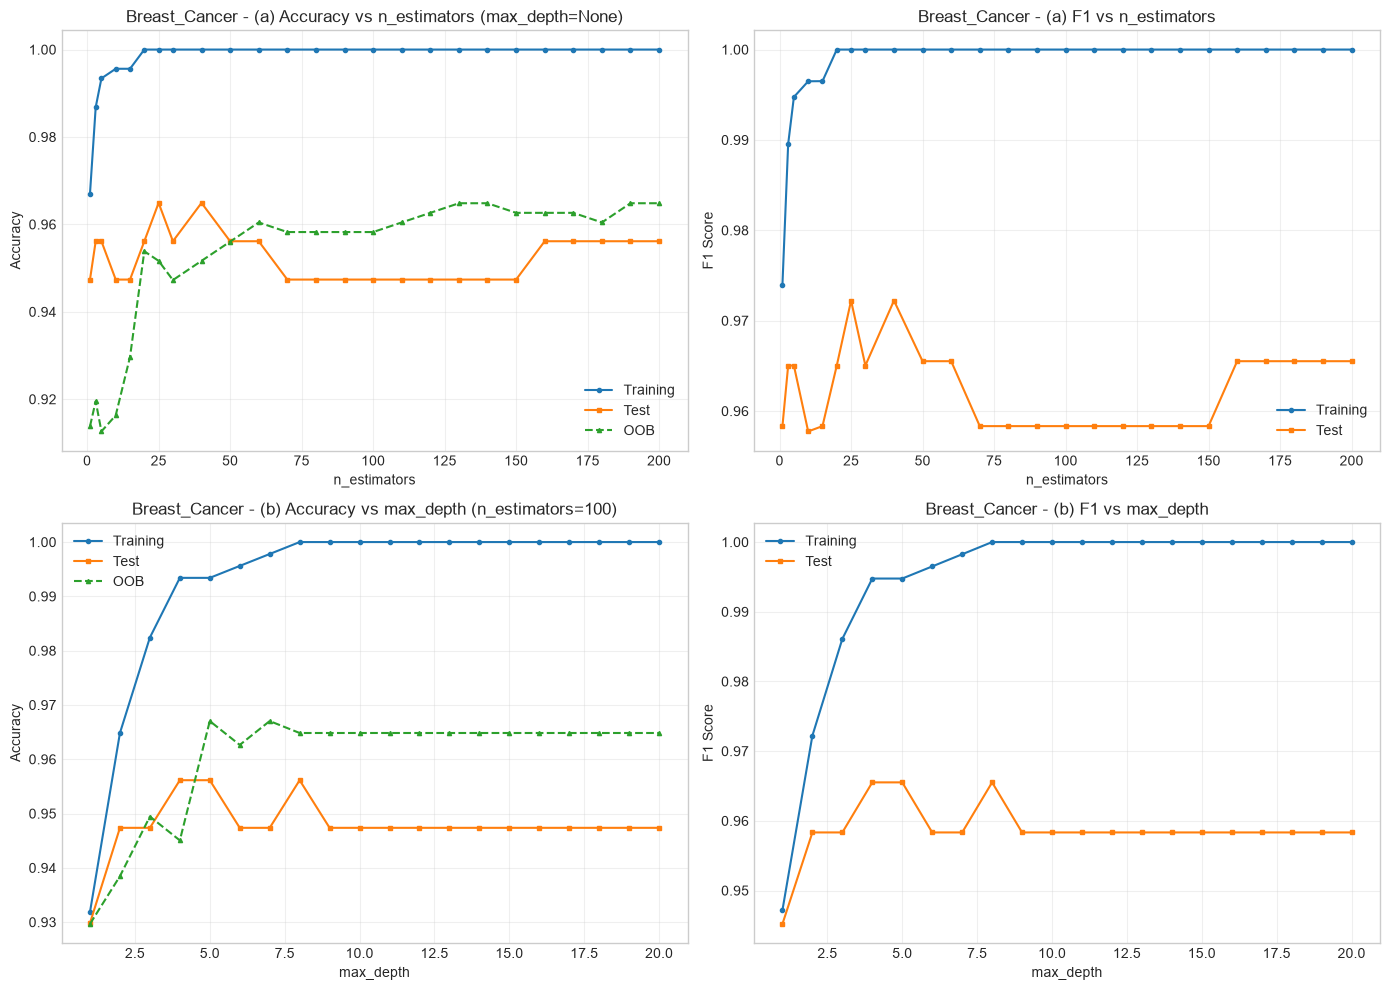


Plotting Adult_Income...
   Figure saved: ../figures/rf_scaling_Adult_Income.png


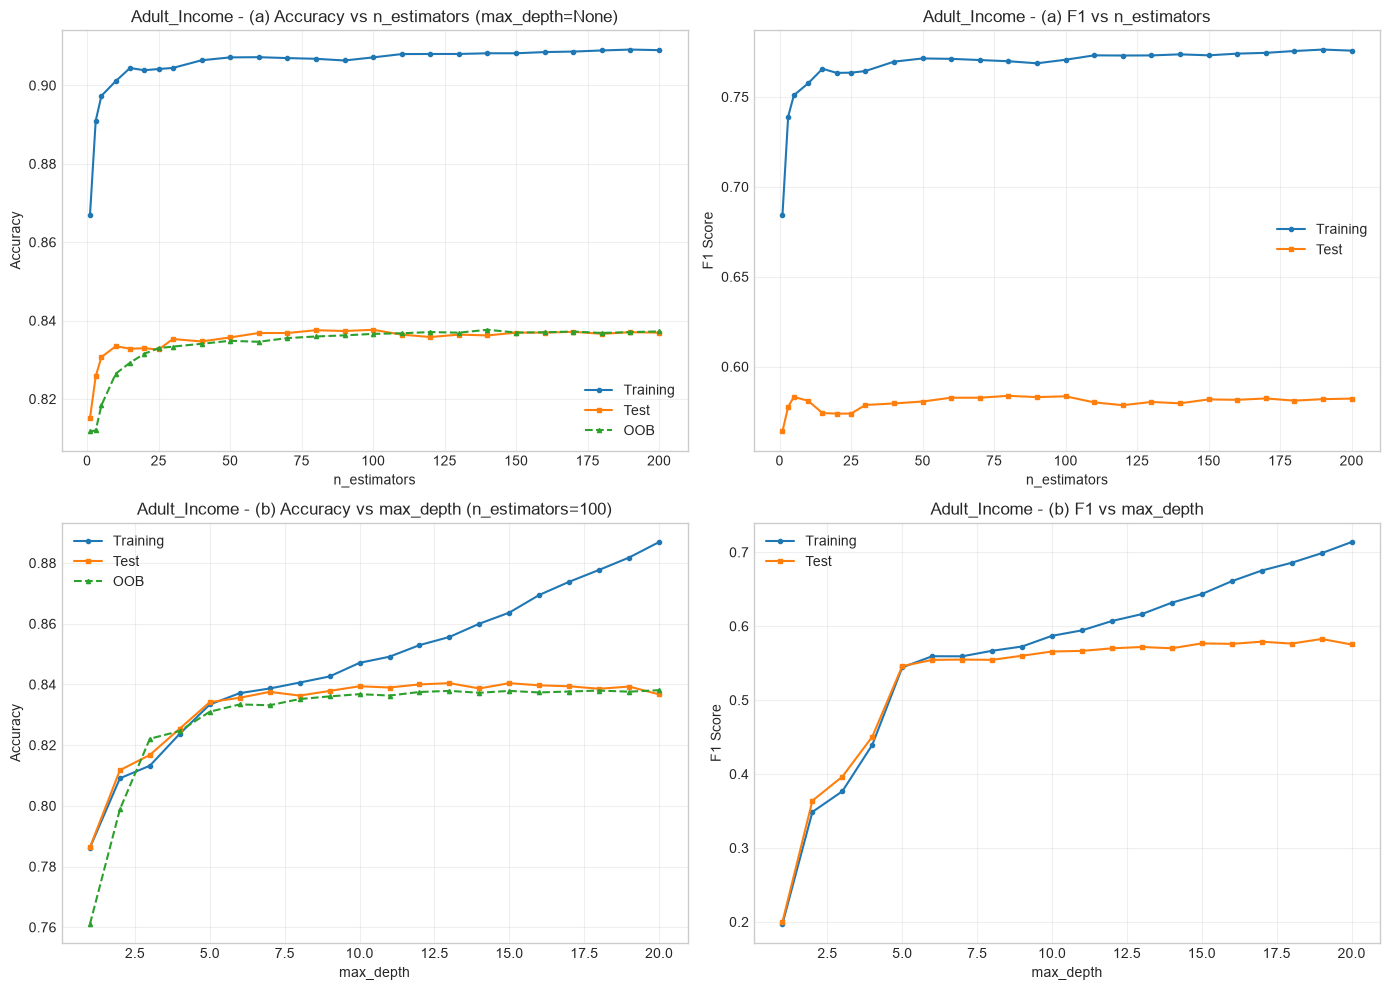


Plotting Covertype...
   Figure saved: ../figures/rf_scaling_Covertype.png


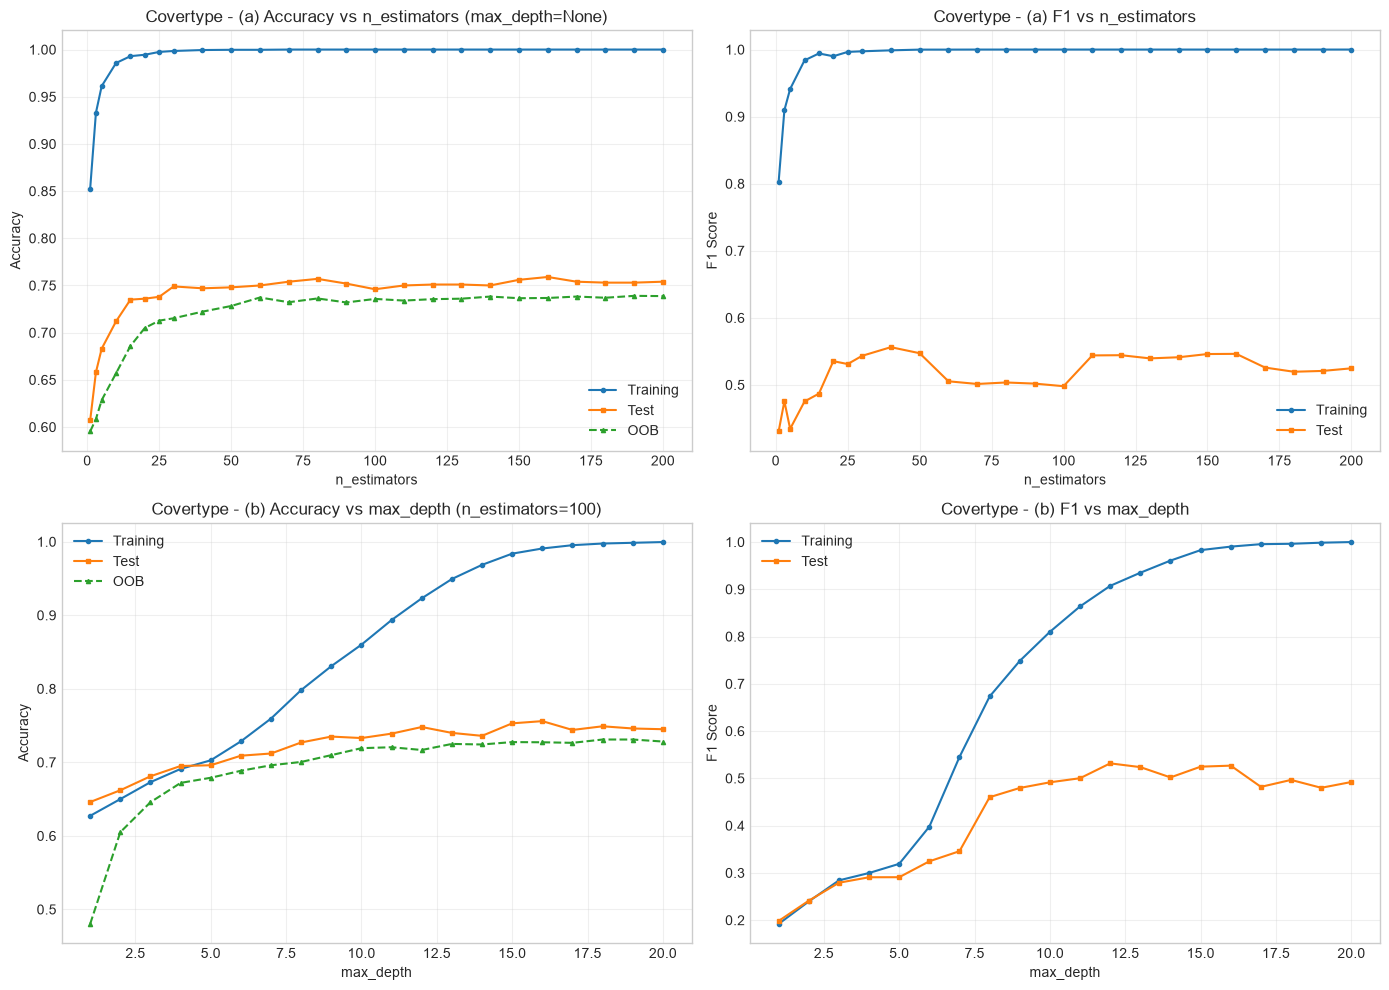


Plotting MNIST...
   Figure saved: ../figures/rf_scaling_MNIST.png


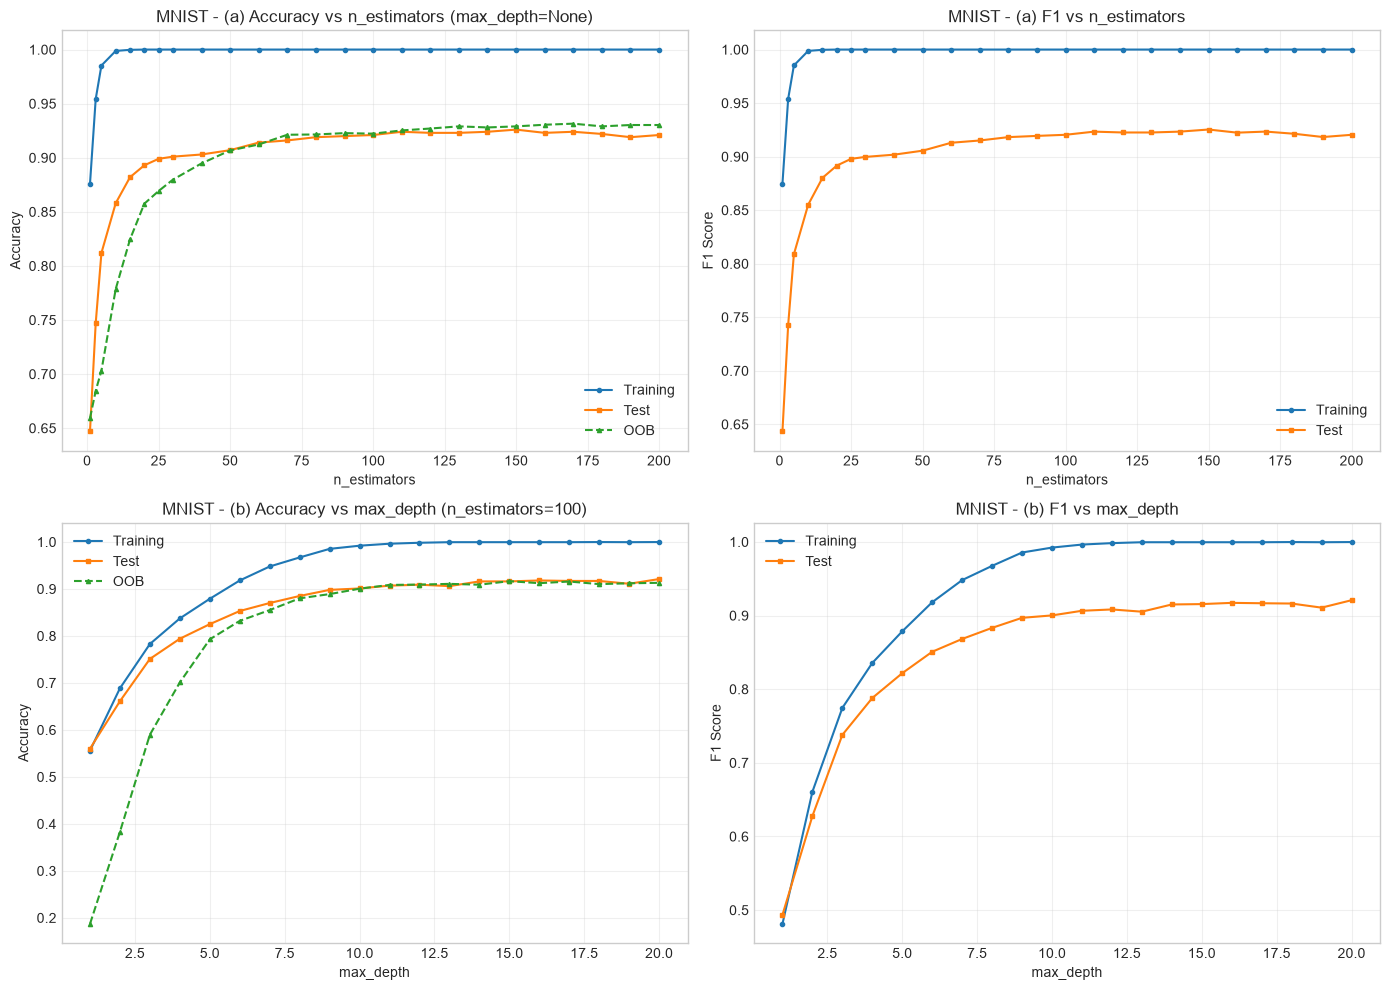

In [11]:
def plot_rf_scaling(result_n, result_depth, save_path=None):
    """
    Plot test/OOB accuracy for both sweeps side by side (2x2 grid):
    top row = (a) n_estimators sweep (accuracy, F1)
    bottom row = (b) max_depth sweep (accuracy, F1)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # --- (a) n_estimators: accuracy ---
    ax = axes[0, 0]
    ax.plot(
        result_n["n_estimators"],
        result_n["train_acc"],
        label="Training",
        marker="o",
        markersize=3,
        linewidth=1.5,
    )
    ax.plot(
        result_n["n_estimators"],
        result_n["test_acc"],
        label="Test",
        marker="s",
        markersize=3,
        linewidth=1.5,
    )
    ax.plot(
        result_n["n_estimators"],
        result_n["oob_acc"],
        label="OOB",
        marker="^",
        markersize=3,
        linewidth=1.5,
        linestyle="--",
    )
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("Accuracy")
    ax.set_title(
        f"{result_n['dataset']} - (a) Accuracy vs n_estimators (max_depth=None)"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- (a) n_estimators: F1 ---
    ax = axes[0, 1]
    ax.plot(
        result_n["n_estimators"],
        result_n["train_f1"],
        label="Training",
        marker="o",
        markersize=3,
        linewidth=1.5,
    )
    ax.plot(
        result_n["n_estimators"],
        result_n["test_f1"],
        label="Test",
        marker="s",
        markersize=3,
        linewidth=1.5,
    )
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("F1 Score")
    ax.set_title(f"{result_n['dataset']} - (a) F1 vs n_estimators")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- (b) max_depth: accuracy ---
    ax = axes[1, 0]
    ax.plot(
        result_depth["max_depth"],
        result_depth["train_acc"],
        label="Training",
        marker="o",
        markersize=3,
        linewidth=1.5,
    )
    ax.plot(
        result_depth["max_depth"],
        result_depth["test_acc"],
        label="Test",
        marker="s",
        markersize=3,
        linewidth=1.5,
    )
    ax.plot(
        result_depth["max_depth"],
        result_depth["oob_acc"],
        label="OOB",
        marker="^",
        markersize=3,
        linewidth=1.5,
        linestyle="--",
    )
    ax.set_xlabel("max_depth")
    ax.set_ylabel("Accuracy")
    ax.set_title(
        f"{result_depth['dataset']} - (b) Accuracy vs max_depth (n_estimators={FIXED_N_FOR_DEPTH})"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- (b) max_depth: F1 ---
    ax = axes[1, 1]
    ax.plot(
        result_depth["max_depth"],
        result_depth["train_f1"],
        label="Training",
        marker="o",
        markersize=3,
    )
    ax.plot(
        result_depth["max_depth"],
        result_depth["test_f1"],
        label="Test",
        marker="s",
        markersize=3,
        linewidth=1.5,
    )
    ax.set_xlabel("max_depth")
    ax.set_ylabel("F1 Score")
    ax.set_title(f"{result_depth['dataset']} - (b) F1 vs max_depth")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        # Ensure figures directory exists
        os.makedirs("../figures", exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"   Figure saved: {save_path}")

    plt.show()


# Generate plots for all datasets
print("\n" + "=" * 60)
print("GENERATING PLOTS")
print("=" * 60)

for name in results_n.keys():
    print(f"\nPlotting {name}...")
    plot_rf_scaling(
        results_n[name],
        results_depth[name],
        save_path=f"../figures/rf_scaling_{name}.png",
    )

# Summary table

In [12]:
# Generate summary of best results for BOTH sweeps
summary = []
for name in results_n.keys():
    result_n = results_n[name]
    result_depth = results_depth[name]

    best_idx_n = int(np.argmax(result_n["test_acc"]))
    best_idx_d = int(np.argmax(result_depth["test_acc"]))

    summary.append(
        {
            "Dataset": name,
            "Best n_estimators": result_n["n_estimators"][best_idx_n],
            "Best Acc (n_estimators sweep)": result_n["test_acc"][best_idx_n],
            "Best OOB Acc (n_estimators sweep)": result_n["oob_acc"][best_idx_n],
            "Best max_depth": result_depth["max_depth"][best_idx_d],
            "Best Acc (max_depth sweep)": result_depth["test_acc"][best_idx_d],
            "Best OOB Acc (max_depth sweep)": result_depth["oob_acc"][best_idx_d],
        }
    )

summary_df = pd.DataFrame(summary)

print("\n" + "=" * 60)
print("RANDOM FOREST SCALING RESULTS SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

best_overall_idx = np.argmax(summary_df["Best Acc (n_estimators sweep)"])
print(
    f"\nBest overall performance (n_estimators sweep): {summary_df.iloc[best_overall_idx]['Dataset']}"
)
print(
    f"   Accuracy: {summary_df.iloc[best_overall_idx]['Best Acc (n_estimators sweep)']:.4f}"
)
print(f"   n_estimators: {summary_df.iloc[best_overall_idx]['Best n_estimators']}")


RANDOM FOREST SCALING RESULTS SUMMARY
      Dataset  Best n_estimators  Best Acc (n_estimators sweep)  Best OOB Acc (n_estimators sweep)  Best max_depth  Best Acc (max_depth sweep)  Best OOB Acc (max_depth sweep)
Breast_Cancer                 25                       0.964912                           0.951648               4                    0.956140                        0.945055
 Adult_Income                100                       0.837650                           0.836614              13                    0.840414                        0.837868
    Covertype                160                       0.759000                           0.736750              16                    0.756000                        0.727250
        MNIST                150                       0.926000                           0.929000              20                    0.921000                        0.913000

Best overall performance (n_estimators sweep): Breast_Cancer
   Accuracy: 0.9649
   n

# Overfitting analysis

**AZ:** Bu bölmə `train_acc - test_acc` fərqini (overfitting "gap"-i) hər iki sweep üçün araşdırır. **Gözlənilən nəticə:** `(a)` sweep-də (ağac sayı artdıqca) gap **sabit qalmalıdır** (bagging overfit etmir), `(b)` sweep-də (dərinlik artdıqca) gap **böyüyə bilər** (tək ağaclar məlumatı əzbərləməyə meyillidir, amma bagging bunu qismən yumşaldır).

**EN:** This section examines the `train_acc - test_acc` gap (the overfitting gap) for both sweeps. **Expected outcome:** in the `(a)` sweep (as tree count grows) the gap should **stay flat** (bagging doesn't overfit), while in the `(b)` sweep (as depth grows) the gap **may widen** (individual trees tend to memorize the data, though bagging cushions this somewhat).



OVERFITTING ANALYSIS

Breast_Cancer:
  (a) n_estimators sweep:
    Best test accuracy: 0.9649 at n_estimators=25
    Final test accuracy: 0.9561
    Max overfitting gap: 0.0526
    Final overfitting gap: 0.0439
  (b) max_depth sweep:
    Best test accuracy: 0.9561 at max_depth=4
    Final test accuracy: 0.9474
    Max overfitting gap: 0.0526
    Final overfitting gap: 0.0526

Adult_Income:
  (a) n_estimators sweep:
    Best test accuracy: 0.8376 at n_estimators=100
    Final test accuracy: 0.8369
    Max overfitting gap: 0.0723
    Final overfitting gap: 0.0721
  (b) max_depth sweep:
    Best test accuracy: 0.8404 at max_depth=13
    Final test accuracy: 0.8367
    Max overfitting gap: 0.0502
    Final overfitting gap: 0.0502

Covertype:
  (a) n_estimators sweep:
    Best test accuracy: 0.7590 at n_estimators=160
    Final test accuracy: 0.7540
    Max overfitting gap: 0.2782
    Final overfitting gap: 0.2460
  (b) max_depth sweep:
    Best test accuracy: 0.7560 at max_depth=16
    Fi

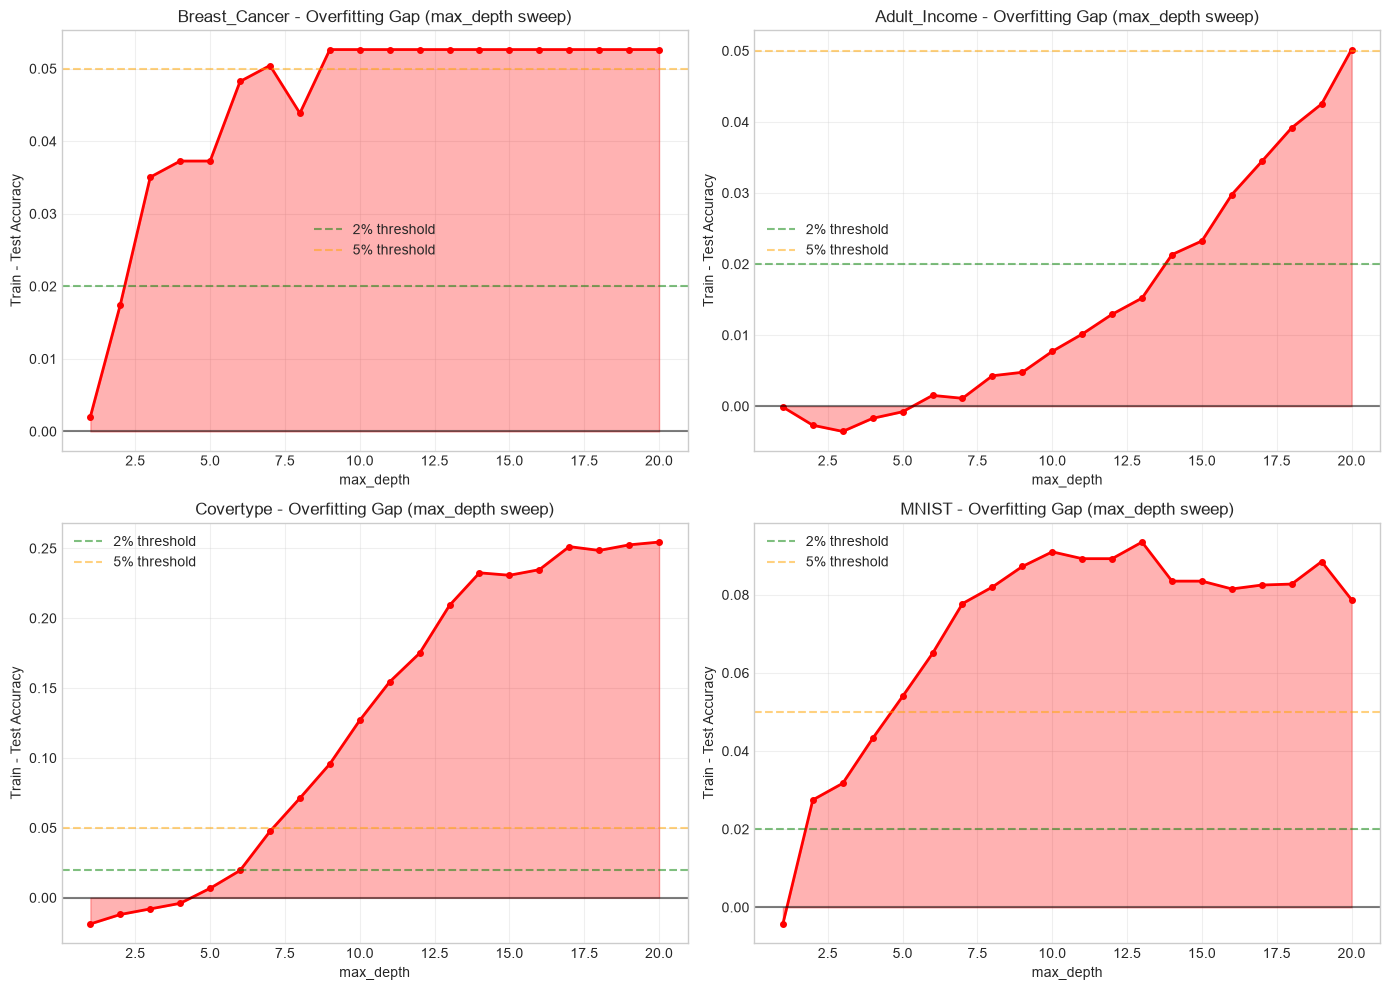


Overfitting analysis figure saved: figures/rf_overfitting_analysis.png


In [13]:
print("\n" + "=" * 60)
print("OVERFITTING ANALYSIS")
print("=" * 60)

for name in results_n.keys():
    print(f"\n{name}:")
    for sweep_label, result, x_key in [
        ("(a) n_estimators sweep", results_n[name], "n_estimators"),
        ("(b) max_depth sweep", results_depth[name], "max_depth"),
    ]:
        train_acc = np.array(result["train_acc"])
        test_acc = np.array(result["test_acc"])
        gap = train_acc - test_acc

        print(f"  {sweep_label}:")
        print(
            f"    Best test accuracy: {max(test_acc):.4f} at {x_key}={result[x_key][np.argmax(test_acc)]}"
        )
        print(f"    Final test accuracy: {test_acc[-1]:.4f}")
        print(f"    Max overfitting gap: {max(gap):.4f}")
        print(f"    Final overfitting gap: {gap[-1]:.4f}")

        if max(gap) > 0.05:
            print("    WARNING: Significant overfitting detected (>5%)")
        elif max(gap) > 0.02:
            print("    Some overfitting detected (2-5%)")
        else:
            print("    No significant overfitting (<2%)")


# Visualize overfitting gaps for the max_depth sweep (most relevant one)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, name in enumerate(results_depth.keys()):
    result = results_depth[name]
    train_acc = np.array(result["train_acc"])
    test_acc = np.array(result["test_acc"])
    gap = train_acc - test_acc

    ax = axes[idx]
    ax.plot(
        result["max_depth"], gap, color="red", linewidth=2, marker="o", markersize=4
    )
    ax.axhline(y=0, color="black", linestyle="-", alpha=0.5)
    ax.axhline(y=0.02, color="green", linestyle="--", alpha=0.5, label="2% threshold")
    ax.axhline(y=0.05, color="orange", linestyle="--", alpha=0.5, label="5% threshold")
    ax.fill_between(result["max_depth"], 0, gap, alpha=0.3, color="red")
    ax.set_xlabel("max_depth")
    ax.set_ylabel("Train - Test Accuracy")
    ax.set_title(f"{name} - Overfitting Gap (max_depth sweep)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/rf_overfitting_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nOverfitting analysis figure saved: figures/rf_overfitting_analysis.png")

# Save all results

In [14]:
os.makedirs("../notebooks", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

print("\n" + "=" * 60)
print("SAVING SUMMARY RESULTS")
print("=" * 60)

# Save summary table
summary_df.to_csv("../notebooks/rf_scaling_summary.csv", index=False)
print("Summary saved: notebooks/rf_scaling_summary.csv")

# Save sklearn comparison
# comparison_df.to_csv("../notebooks/rf_scaling_sklearn_comparison.csv", index=False)
# print("sklearn comparison saved: notebooks/rf_scaling_sklearn_comparison.csv")

# Save experiment metadata
metadata = {
    "experiment": "Random Forest Scaling (a: n_estimators, b: max_depth)",
    "date": time.strftime("%Y-%m-%d %H:%M:%S"),
    "max_estimators": MAX_ESTIMATORS,
    "step": STEP,
    "max_depth_values": MAX_DEPTH_VALUES,
    "fixed_n_estimators_for_depth_sweep": FIXED_N_FOR_DEPTH,
    "datasets": list(datasets.keys()),
    "covertype_sample_size": COVERTYPE_SAMPLE_SIZE,
    "mnist_sample_size": MNIST_SAMPLE_SIZE,
    "total_time_seconds": TOTAL_TIME,
    "results_summary": summary_df.to_dict(orient="records"),
}

with open("../notebooks/rf_scaling_experiment_metadata.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["key", "value"])
    for key, value in metadata.items():
        if key not in ("results_summary", "max_depth_values"):
            writer.writerow([key, value])
        elif key == "max_depth_values":
            writer.writerow([key, str(value)])

print("Metadata saved: notebooks/rf_scaling_experiment_metadata.csv")

print("\n" + "=" * 60)
print("ALL RESULTS SAVED SUCCESSFULLY")
print("=" * 60)
print("  Individual dataset results: notebooks/rf_scaling_{sweep}_*_details.csv")
print("  Individual metadata: notebooks/rf_scaling_{sweep}_*_metadata.csv")
print("  Summary: notebooks/rf_scaling_summary.csv")
print("  sklearn comparison: notebooks/rf_scaling_sklearn_comparison.csv")
print("=" * 60)


SAVING SUMMARY RESULTS
Summary saved: notebooks/rf_scaling_summary.csv
Metadata saved: notebooks/rf_scaling_experiment_metadata.csv

ALL RESULTS SAVED SUCCESSFULLY
  Individual dataset results: notebooks/rf_scaling_{sweep}_*_details.csv
  Individual metadata: notebooks/rf_scaling_{sweep}_*_metadata.csv
  Summary: notebooks/rf_scaling_summary.csv
  sklearn comparison: notebooks/rf_scaling_sklearn_comparison.csv


# Final summary output

In [15]:
print("\nDATASETS SUMMARY")
print("-" * 40)
for name, (X, y) in datasets.items():
    if name == "Covertype":
        sample_size = (
            COVERTYPE_SAMPLE_SIZE if COVERTYPE_SAMPLE_SIZE is not None else X.shape[0]
        )
        full_size = X.shape[0]
    elif name == "MNIST":
        sample_size = MNIST_SAMPLE_SIZE if MNIST_SAMPLE_SIZE is not None else X.shape[0]
        full_size = X.shape[0]
    else:
        sample_size = X.shape[0]
        full_size = X.shape[0]

    print(f"  {name}:")
    if name in ["Covertype", "MNIST"] and sample_size != full_size:
        print(f"    Samples: {sample_size:,} (subsampled from {full_size:,})")
    else:
        print(f"    Samples: {sample_size:,}")
    print(f"    Features: {X.shape[1]}")
    print(f"    Classes: {len(np.unique(y))}")

print("\nBEST RESULTS PER DATASET")
print("-" * 40)
print(summary_df.to_string(index=False))

print("\nKEY FINDINGS")
print("-" * 40)

best_row = summary_df.loc[summary_df["Best Acc (n_estimators sweep)"].idxmax()]
print(f"  Best Overall Accuracy (n_estimators sweep): {best_row['Dataset']}")
print(f"     Accuracy: {best_row['Best Acc (n_estimators sweep)']:.4f}")
print(f"     n_estimators: {best_row['Best n_estimators']}")

# Save the summary table to the new directory
summary_path = "../rf_scaling_files/rf_scaling_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\nSummary table saved to: {summary_path}")

# Save Key Findings to a text file in the same folder
findings_path = "../rf_scaling_files/rf_scaling_key_findings.txt"
with open(findings_path, "w") as f:
    f.write("KEY FINDINGS\n")
    f.write("-" * 40 + "\n")
    best_row = summary_df.loc[summary_df["Best Acc (n_estimators sweep)"].idxmax()]
    f.write(f"Best Overall Accuracy (n_estimators sweep): {best_row['Dataset']}\n")
    f.write(f"    Accuracy: {best_row['Best Acc (n_estimators sweep)']:.4f}\n")
    f.write(f"    n_estimators: {best_row['Best n_estimators']}\n")

print(f"Key findings saved to: {findings_path}")

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETE")
print("=" * 60)


DATASETS SUMMARY
----------------------------------------
  Breast_Cancer:
    Samples: 569
    Features: 30
    Classes: 2
  Adult_Income:
    Samples: 48,842
    Features: 6
    Classes: 2
  Covertype:
    Samples: 5,000
    Features: 10
    Classes: 7
  MNIST:
    Samples: 5,000
    Features: 784
    Classes: 10

BEST RESULTS PER DATASET
----------------------------------------
      Dataset  Best n_estimators  Best Acc (n_estimators sweep)  Best OOB Acc (n_estimators sweep)  Best max_depth  Best Acc (max_depth sweep)  Best OOB Acc (max_depth sweep)
Breast_Cancer                 25                       0.964912                           0.951648               4                    0.956140                        0.945055
 Adult_Income                100                       0.837650                           0.836614              13                    0.840414                        0.837868
    Covertype                160                       0.759000                           

In [16]:
time_end = time.perf_counter()

print(f"the notebook took {time_end - time_start:.3f} seconds to run")

the notebook took 699.932 seconds to run
